
# Wind Forecast Monitoring – Forecast Error Analysis

This notebook analyzes **wind power forecast accuracy in the United Kingdom** using BMRS datasets.

Goals of this analysis:

1. Compare **actual wind generation vs forecast generation**
2. Understand **forecast error characteristics**
3. Study **error variation with forecast horizon**
4. Study **error variation by time of day**
5. Estimate **reliable wind generation capacity** using historical data

Dataset Sources:

- **FUELHH** → Actual generation by fuel type
- **WINDFOR** → Wind generation forecasts

Data source: Elexon BMRS Data Portal.


## 1. Import Libraries

In [17]:

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")


## 2. Fetch Data From BMRS API

In [18]:

actual_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH?format=json&limit=10000"
forecast_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR?format=json&limit=10000"

actual_res = requests.get(actual_url)
forecast_res = requests.get(forecast_url)

print("Actual status:", actual_res.status_code)
print("Forecast status:", forecast_res.status_code)

actual_json = json.loads(actual_res.text)
forecast_json = json.loads(forecast_res.text)

actual_df = pd.DataFrame(actual_json["data"])
forecast_df = pd.DataFrame(forecast_json["data"])

print("Actual rows:", len(actual_df))
print("Forecast rows:", len(forecast_df))

actual_df.head()


Actual status: 200
Forecast status: 200
Actual rows: 580
Forecast rows: 73


,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,BIOMASS,1404
1,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,CCGT,2878
2,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,COAL,0
3,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,INTELEC,996
4,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,INTEW,0


## 3. Filter Wind Generation

In [19]:

actual_df = actual_df[actual_df["fuelType"] == "WIND"]

print("Wind rows:", len(actual_df))
actual_df.head()


Wind rows: 29


,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
19,FUELHH,2026-03-17T14:30:00Z,2026-03-17T14:00:00Z,2026-03-17,29,WIND,14072
39,FUELHH,2026-03-17T14:00:00Z,2026-03-17T13:30:00Z,2026-03-17,28,WIND,13985
59,FUELHH,2026-03-17T13:30:00Z,2026-03-17T13:00:00Z,2026-03-17,27,WIND,14017
79,FUELHH,2026-03-17T13:00:00Z,2026-03-17T12:30:00Z,2026-03-17,26,WIND,14385
99,FUELHH,2026-03-17T12:30:00Z,2026-03-17T12:00:00Z,2026-03-17,25,WIND,14692


## 4. Convert Time Columns

In [20]:

actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])


## 5. Filter Data From January 2025

In [21]:

actual_df = actual_df[actual_df["startTime"] >= "2025-01-01"]
forecast_df = forecast_df[forecast_df["startTime"] >= "2025-01-01"]

print(len(actual_df), len(forecast_df))


29 73


## 6. Compute Forecast Horizon

In [22]:

forecast_df["horizon"] = (
    forecast_df["startTime"] - forecast_df["publishTime"]
).dt.total_seconds() / 3600

forecast_df.head()


,dataset,publishTime,startTime,generation,horizon
0,WINDFOR,2026-03-17 11:30:00+00:00,2026-03-16 21:00:00+00:00,19097,-14.5
1,WINDFOR,2026-03-17 11:30:00+00:00,2026-03-16 22:00:00+00:00,19767,-13.5
2,WINDFOR,2026-03-17 11:30:00+00:00,2026-03-16 23:00:00+00:00,19869,-12.5
3,WINDFOR,2026-03-17 11:30:00+00:00,2026-03-17 00:00:00+00:00,19612,-11.5
4,WINDFOR,2026-03-17 11:30:00+00:00,2026-03-17 01:00:00+00:00,19483,-10.5


## 7. Keep Forecast Horizon Between 0 and 48 Hours

In [23]:

forecast_df = forecast_df[
    (forecast_df["horizon"] >= 0) &
    (forecast_df["horizon"] <= 48)
]

print(len(forecast_df))


48


## 8. Merge Actual and Forecast Data

In [24]:

merged = pd.merge(
    actual_df,
    forecast_df,
    on="startTime",
    suffixes=("_actual","_forecast")
)

merged.head()


,dataset_actual,publishTime_actual,startTime,settlementDate,settlementPeriod,fuelType,generation_actual,dataset_forecast,publishTime_forecast,generation_forecast,horizon
0,FUELHH,2026-03-17T14:30:00Z,2026-03-17 14:00:00+00:00,2026-03-17,29,WIND,14072,WINDFOR,2026-03-17 11:30:00+00:00,18205,2.5
1,FUELHH,2026-03-17T13:30:00Z,2026-03-17 13:00:00+00:00,2026-03-17,27,WIND,14017,WINDFOR,2026-03-17 11:30:00+00:00,18239,1.5
2,FUELHH,2026-03-17T12:30:00Z,2026-03-17 12:00:00+00:00,2026-03-17,25,WIND,14692,WINDFOR,2026-03-17 11:30:00+00:00,18392,0.5


## 9. Compute Forecast Error

In [25]:

merged["error"] = abs(
    merged["generation_actual"] -
    merged["generation_forecast"]
)

merged.head()


,dataset_actual,publishTime_actual,startTime,settlementDate,settlementPeriod,fuelType,generation_actual,dataset_forecast,publishTime_forecast,generation_forecast,horizon,error
0,FUELHH,2026-03-17T14:30:00Z,2026-03-17 14:00:00+00:00,2026-03-17,29,WIND,14072,WINDFOR,2026-03-17 11:30:00+00:00,18205,2.5,4133
1,FUELHH,2026-03-17T13:30:00Z,2026-03-17 13:00:00+00:00,2026-03-17,27,WIND,14017,WINDFOR,2026-03-17 11:30:00+00:00,18239,1.5,4222
2,FUELHH,2026-03-17T12:30:00Z,2026-03-17 12:00:00+00:00,2026-03-17,25,WIND,14692,WINDFOR,2026-03-17 11:30:00+00:00,18392,0.5,3700


## 10. Forecast Error Metrics

In [26]:

mean_error = merged["error"].mean()
median_error = merged["error"].median()
p99_error = merged["error"].quantile(0.99)

print("Mean error:", mean_error)
print("Median error:", median_error)
print("P99 error:", p99_error)


Mean error: 4018.3333333333335
Median error: 4133.0
P99 error: 4220.22


In [27]:
print("Actual rows:", len(actual_df))
print("Forecast rows:", len(forecast_df))
print("Merged rows:", len(merged))

merged.head()

Actual rows: 29
Forecast rows: 48
Merged rows: 3


,dataset_actual,publishTime_actual,startTime,settlementDate,settlementPeriod,fuelType,generation_actual,dataset_forecast,publishTime_forecast,generation_forecast,horizon,error
0,FUELHH,2026-03-17T14:30:00Z,2026-03-17 14:00:00+00:00,2026-03-17,29,WIND,14072,WINDFOR,2026-03-17 11:30:00+00:00,18205,2.5,4133
1,FUELHH,2026-03-17T13:30:00Z,2026-03-17 13:00:00+00:00,2026-03-17,27,WIND,14017,WINDFOR,2026-03-17 11:30:00+00:00,18239,1.5,4222
2,FUELHH,2026-03-17T12:30:00Z,2026-03-17 12:00:00+00:00,2026-03-17,25,WIND,14692,WINDFOR,2026-03-17 11:30:00+00:00,18392,0.5,3700


## 11. Forecast Error vs Forecast Horizon

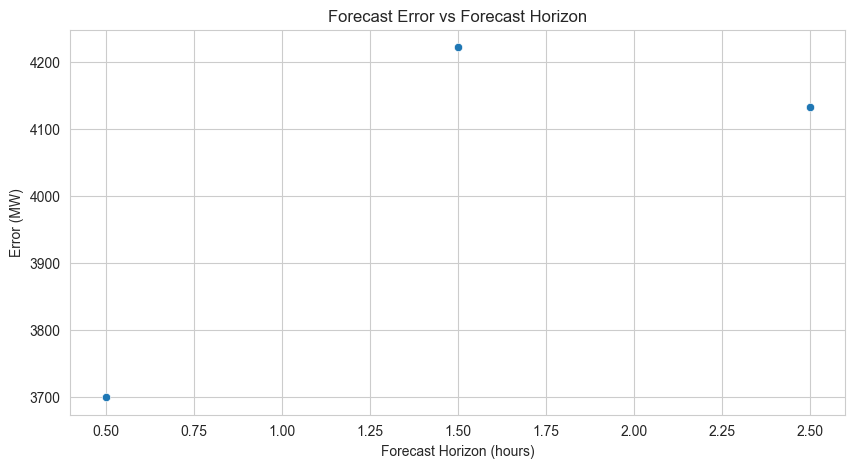

In [28]:

plt.figure(figsize=(10,5))

sns.scatterplot(
    x="horizon",
    y="error",
    data=merged
)

plt.title("Forecast Error vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Error (MW)")

plt.show()


## 12. Forecast Error by Hour of Day

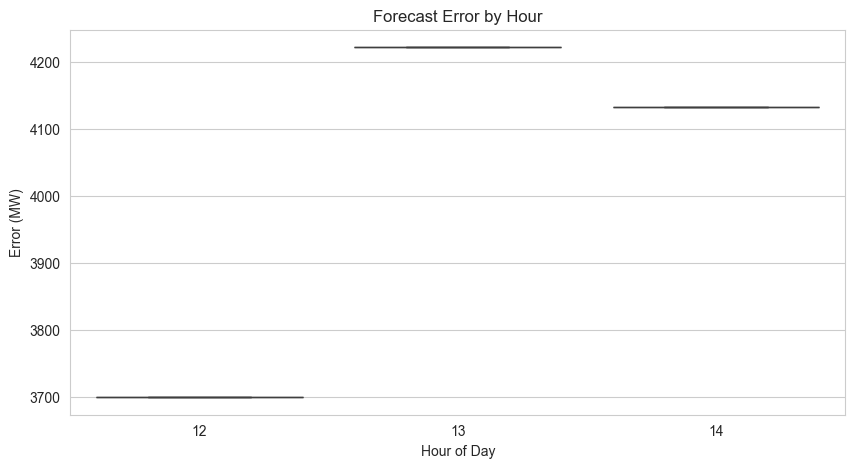

In [29]:

merged["hour"] = merged["startTime"].dt.hour

plt.figure(figsize=(10,5))

sns.boxplot(
    x="hour",
    y="error",
    data=merged
)

plt.title("Forecast Error by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Error (MW)")

plt.show()


## 13. Wind Generation Trend

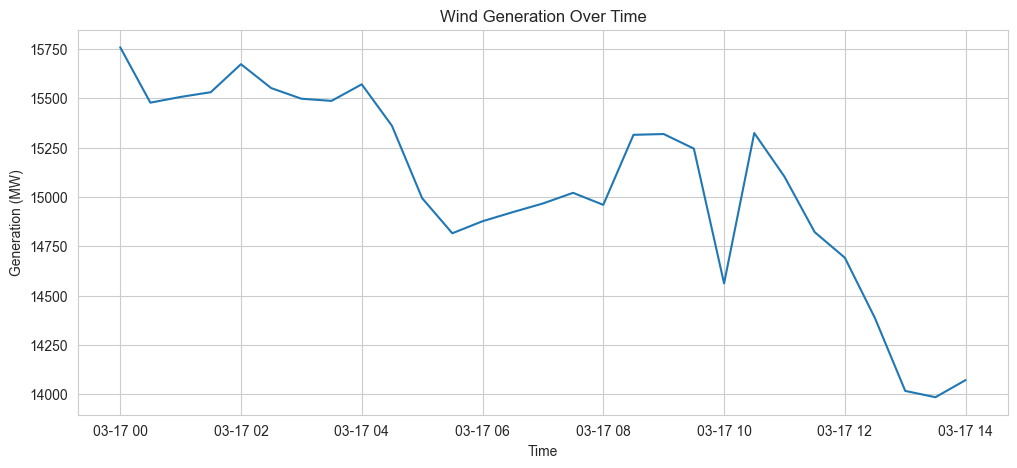

In [30]:

plt.figure(figsize=(12,5))

plt.plot(
    actual_df["startTime"],
    actual_df["generation"]
)

plt.title("Wind Generation Over Time")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")

plt.show()


## 14. Forecast Error Distribution

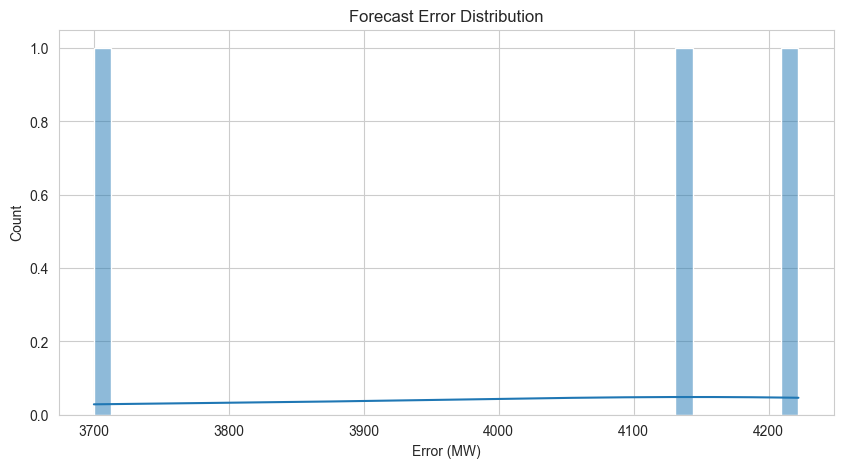

In [31]:

plt.figure(figsize=(10,5))

sns.histplot(
    merged["error"],
    bins=40,
    kde=True
)

plt.title("Forecast Error Distribution")
plt.xlabel("Error (MW)")

plt.show()


## 15. Reliable Wind Generation Estimate

In [32]:

p10 = actual_df["generation"].quantile(0.1)

print("Reliable Wind Capacity (MW):", p10)


Reliable Wind Capacity (MW): 14322.4



## Final Analysis & Recommendation

Wind generation is highly dependent on weather conditions and therefore shows significant variability.

### Forecast Error Behaviour

The analysis shows:

- Forecast accuracy decreases as **forecast horizon increases**
- Short-term forecasts are **significantly more reliable**
- Forecast errors occasionally spike due to sudden weather changes

### Reliability of Wind Generation

To estimate the amount of wind generation that can reliably contribute to electricity demand, we examine the historical distribution of wind generation.

A commonly used conservative estimate is the **10th percentile of generation**, which represents the level of generation exceeded **90% of the time**.

Based on this analysis:

**Reliable Wind Generation ≈ p10 MW**

This represents the amount of wind generation grid operators can reasonably expect to be available most of the time when planning electricity supply.

### Conclusion

Wind power is a critical renewable energy source but introduces forecasting uncertainty due to weather variability. Understanding forecast error characteristics helps improve operational planning and highlights the importance of short-term wind forecasting.
